# EDA de audio

<div style="border-left: 4px solid #f0ad4e; padding: 0.5em 1em; background: #f5f5f5; color: black;">
<b>Atención! (Solo para quienes usen Conda): esta notebook requiere utilizar el env add-aml</b>

```bash
(conda env create -f environment_bonus.yml)
```

### Objetivo
Entender el rango de duraciones, volúmenes, tipos de sonidos, presencia de ruido, etc., antes de extraer features más complejas o aplicar modelos.

Qué analizamos en un audio:

- Duración
- Amplitud / volumen.
- Espectrogramas
- Formas de onda.
- Análisis de pitch (para analizar entonación, melodía, etc.,  para distinguir voces, instrumentos, emociones).
- Distribución de clases (si es clasificación)
- etc.


In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import IPython.display as ipd

In [2]:
# Audios descargados de https://pixabay.com/sound-effects/search/voice/
mp3_files = ['../audio/medieval-gamer-voice.mp3', '../audio/acoustic-guitar.mp3', 
             '../audio/woman-voice-very-nice.mp3', '../audio/train-voice.mp3']

In [3]:
# Listas para almacenar la información de los audios

amplitudes = []
labels = []
duraciones = []
sample_rates = []

# Carga y procesa cada archivo MP3
for mp3_file in mp3_files:
    try:
        y, sr = librosa.load(mp3_file, sr=None, mono=True)
        y_fixed = y
        n_samples = int(5 * sr)      # máximo 5 segundos
        if len(y) > n_samples:
            y_fixed = y[:n_samples]  # recorta
        
        dur = librosa.get_duration(y=y_fixed, sr=sr)
        duraciones.append(dur)
        amplitudes.append(y_fixed)
        sample_rates.append(sr)
        labels.append(mp3_file)
        print(f"Procesado: {mp3_file}")
    except Exception as e:
        print(f"Error al procesar {mp3_file}: {e}")

if not amplitudes:
    raise ValueError("No se cargaron datos de los archivos MP3.")


Procesado: ../audio/medieval-gamer-voice.mp3
Procesado: ../audio/acoustic-guitar.mp3
Procesado: ../audio/woman-voice-very-nice.mp3
Procesado: ../audio/train-voice.mp3


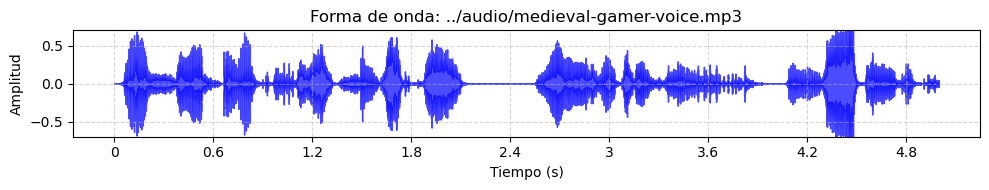

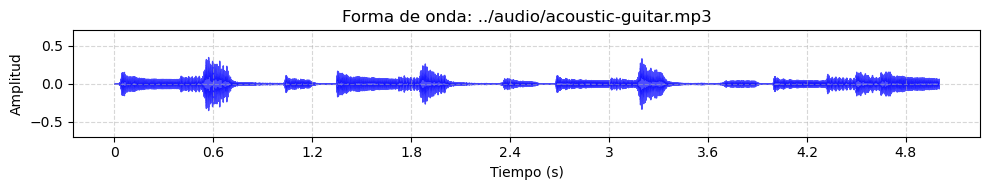

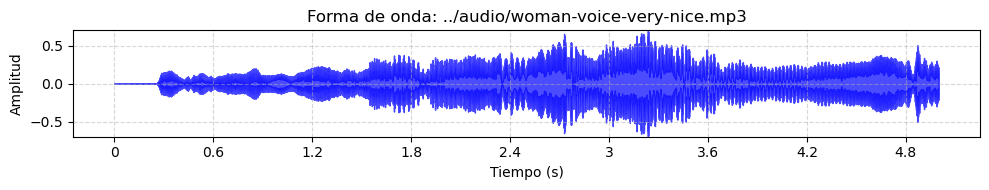

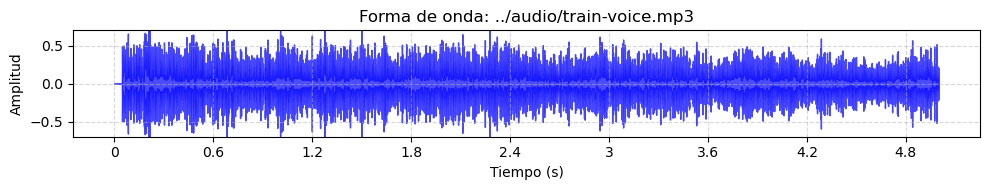

In [4]:
for i, (y, sr, label) in enumerate(zip(amplitudes, sample_rates, labels)):
    # Ondas
    plt.figure(figsize=(10, 2))
    librosa.display.waveshow(y, sr=sr, color='blue', alpha=0.7)
    plt.title(f'Forma de onda: {label}')
    plt.ylabel('Amplitud')
    plt.ylim(-0.7, 0.7)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xlabel('Tiempo (s)')
    plt.tight_layout()
    plt.show()

    # Reproductor
    display(ipd.Audio(y, rate=sr))


/var/folders/23/zrfz0d3122vgprxbdczqhkm80000gn/T/ipykernel_3327/2112169784.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(amplitudes, labels=labels, notch=True, vert=True)


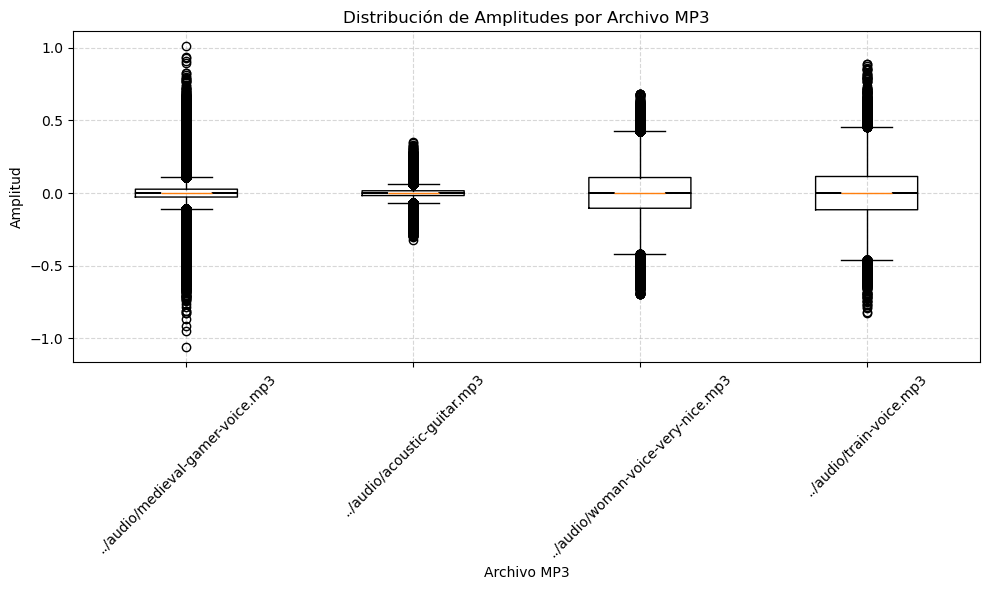

In [5]:
# Boxplot de amplitudes
plt.figure(figsize=(10, 6))
plt.boxplot(amplitudes, labels=labels, notch=True, vert=True)
plt.title('Distribución de Amplitudes por Archivo MP3')
plt.xlabel('Archivo MP3')
plt.ylabel('Amplitud')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

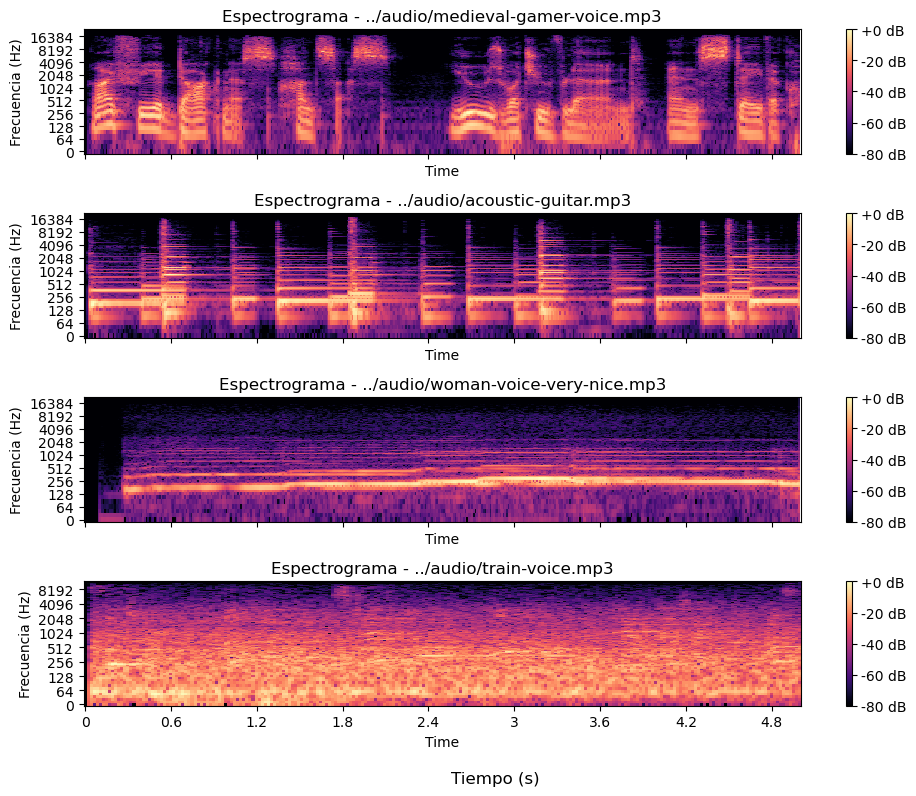

In [6]:
# Espectrogramas
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 8), sharex=True)

for i, (y, sr, label, ax) in enumerate(zip(amplitudes, sample_rates, labels, axes)):

    # Calcular el STFT y convertir a decibeles
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    spec = librosa.display.specshow(D, y_axis='log', x_axis='time', sr=sr, ax=ax)
    ax.set_title(f'Espectrograma - {label}')
    ax.set_ylabel('Frecuencia (Hz)')
    fig.colorbar(spec, ax=ax, format='%+2.0f dB')

# Etiqueta común para el eje x
fig.supxlabel('Tiempo (s)')
plt.tight_layout()
plt.show()